## Importing Libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

### Training Image Preprocessing

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 29469 files belonging to 8 classes.


### Validation Image Preprocessing

In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 4160 files belonging to 8 classes.


In [4]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 8), dtype=tf.float32, name=None))>

In [5]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  ...

  [[  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]

  [[  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  0.   0.   0.]
   [  0.   0.   0.]
   [  0.   0.   0.]]]


 [[[  0.   2.   9.]
   [ 13.   8.  15.]
   [  0.   0.   9.]
   ...
   [  0.   4.   0.]
   [248. 251. 255.]
   [  1.   3.   0.]]

  [[195. 201. 201.]
   [ 21.  22.  16.]
   [112. 125. 115.]
   ...
   [159. 1

### To avoid Overshooting
1. Choose small learning rate default 0.001 here we have taken 0.0001 
2. There may be chance of underfitting so increase number of neuron 
3. Add more Convolutional Layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Model

In [6]:
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.models import Sequential

In [7]:
model = Sequential()

## Building Convolution Layer

In [8]:
model.add(Input(shape=(128, 128, 3)))

In [9]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))

In [10]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [11]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [12]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [13]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [14]:
model.add(Dropout(0.25)) # To avoid Overfitting

In [15]:
model.add(Flatten())

In [16]:
model.add(Dense(units=1500,activation='relu'))

In [17]:
model.add(Dropout(0.4))

In [18]:
#Output Layer
model.add(Dense(units=8,activation='softmax'))

## Compiling Model

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1500)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │          12,008 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,797,732 (29.75 MB)

 Trainable params: 7,797,732 (29.75 MB)

 Non-trainable params: 0 (0.00 B)

## Training Model

In [21]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 493s 531ms/step - accuracy: 0.6657 - loss: 0.8659 - val_accuracy: 0.8531 - val_loss: 0.4254
Epoch 2/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 465s 505ms/step - accuracy: 0.8922 - loss: 0.3074 - val_accuracy: 0.9349 - val_loss: 0.1821
Epoch 3/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 451s 490ms/step - accuracy: 0.9440 - loss: 0.1663 - val_accuracy: 0.9837 - val_loss: 0.0575
Epoch 4/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 442s 480ms/step - accuracy: 0.9609 - loss: 0.1143 - val_accuracy: 0.9750 - val_loss: 0.0792
Epoch 5/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 457s 496ms/step - accuracy: 0.9699 - loss: 0.0871 - val_accuracy: 0.9825 - val_loss: 0.0604
Epoch 6/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 453s 491ms/step - accuracy: 0.9809 - loss: 0.0600 - val_accuracy: 0.9911 - val_loss: 0.0269
Epoch 7/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 443s 481ms/step - accuracy: 0.9829 - loss: 0.0503 - val_accuracy: 0.9841 - val_loss: 0.0623
Epoch 8/10
921/921 ━━━━━━━━━━━━━━━━━━━━ 462s 501ms/step - accuracy: 0.9836 -

## Evaluating Model

In [22]:
# Model Evaluation on Training set
train_loss, train_acc = model.evaluate(training_set)

921/921 ━━━━━━━━━━━━━━━━━━━━ 114s 124ms/step - accuracy: 0.9972 - loss: 0.0084


In [23]:
print(train_loss, train_acc)

0.008439482189714909 0.9972174167633057


In [24]:
# Model on Validation set
val_loss, val_acc = model.evaluate(validation_set)

130/130 ━━━━━━━━━━━━━━━━━━━━ 17s 131ms/step - accuracy: 0.9901 - loss: 0.0323


In [25]:
print(val_loss, val_acc)

0.03225170820951462 0.9901442527770996


## Saving Model

In [26]:
model.save("trained_model.keras")

In [27]:
training_history.history

{'accuracy': [0.6656825542449951,
  0.8921578526496887,
  0.9440429210662842,
  0.9608741402626038,
  0.9699005484580994,
  0.980861246585846,
  0.9829311966896057,
  0.9836438298225403,
  0.9879873991012573,
  0.9884963631629944],
 'loss': [0.8658789992332458,
  0.3074055016040802,
  0.16625501215457916,
  0.11431415379047394,
  0.08706896007061005,
  0.059999845921993256,
  0.05031373351812363,
  0.04819979518651962,
  0.03763984888792038,
  0.03427355736494064],
 'val_accuracy': [0.8531249761581421,
  0.9348557591438293,
  0.9836538434028625,
  0.9750000238418579,
  0.9824519157409668,
  0.9911057949066162,
  0.9841346144676208,
  0.9834134578704834,
  0.9906250238418579,
  0.9901442527770996],
 'val_loss': [0.4254205822944641,
  0.18207599222660065,
  0.05751383304595947,
  0.07917597144842148,
  0.06039249897003174,
  0.026864735409617424,
  0.06231940910220146,
  0.05267512798309326,
  0.02985871210694313,
  0.03225169703364372]}

In [28]:
# Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [29]:
training_history.history['accuracy']

[0.6656825542449951,
 0.8921578526496887,
 0.9440429210662842,
 0.9608741402626038,
 0.9699005484580994,
 0.980861246585846,
 0.9829311966896057,
 0.9836438298225403,
 0.9879873991012573,
 0.9884963631629944]

In [30]:
training_history.history['val_accuracy']

[0.8531249761581421,
 0.9348557591438293,
 0.9836538434028625,
 0.9750000238418579,
 0.9824519157409668,
 0.9911057949066162,
 0.9841346144676208,
 0.9834134578704834,
 0.9906250238418579,
 0.9901442527770996]

### Accuracy Visualization

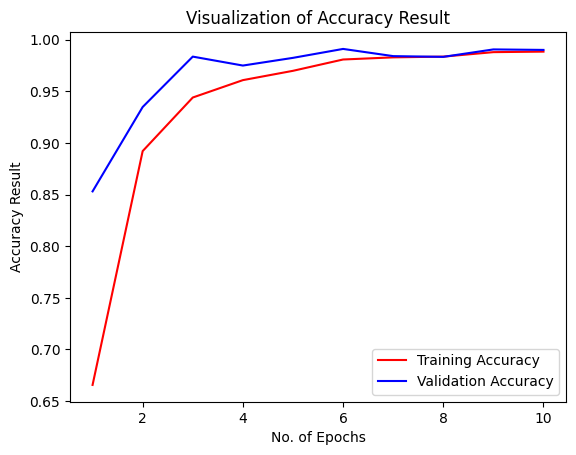

In [31]:
epochs = [i for i in range (1,11)]
plt.plot(epochs, training_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

### Some other metrics for model evaluation

In [32]:
class_name = validation_set.class_names
class_name

['Bacterial Blight',
 'Brown Spot',
 'Dead Heart',
 'Downy Mildew',
 'Healthy',
 'Leaf Blast',
 'Sheath Blight',
 'Streak Virus']

In [33]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 4160 files belonging to 8 classes.


In [34]:
y_pred = model.predict(test_set)
y_pred, y_pred.shape

130/130 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step


(array([[9.9999940e-01, 7.2223409e-09, 2.0663265e-11, ..., 6.3066938e-07,
         8.1818263e-10, 1.6314372e-11],
        [9.9999928e-01, 9.2736689e-09, 7.0939837e-11, ..., 6.5971284e-07,
         1.5745093e-09, 1.7512717e-11],
        [9.9999964e-01, 1.4711211e-10, 1.6481567e-13, ..., 3.7309351e-07,
         2.1617172e-10, 1.7346536e-11],
        ...,
        [7.7647735e-07, 1.4757481e-06, 1.6682548e-04, ..., 5.3311058e-09,
         5.6163682e-08, 9.9974853e-01],
        [5.0787768e-19, 2.5939486e-17, 1.9098080e-16, ..., 1.7597221e-21,
         1.7766074e-18, 1.0000000e+00],
        [5.9887935e-16, 2.2082718e-14, 2.3037495e-14, ..., 1.1916846e-18,
         1.5383550e-15, 1.0000000e+00]], shape=(4160, 8), dtype=float32),
 (4160, 8))

In [35]:
predicted_categories = tf.argmax(y_pred, axis=1)
predicted_categories

<tf.Tensor: shape=(4160,), dtype=int64, numpy=array([0, 0, 0, ..., 7, 7, 7], shape=(4160,))>

In [36]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(4160, 8), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(4160, 8), dtype=float32)>

In [37]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(4160,), dtype=int64, numpy=array([0, 0, 0, ..., 7, 7, 7], shape=(4160,))>

In [38]:
from sklearn.metrics import classification_report, confusion_matrix

In [39]:
print(classification_report(Y_true, predicted_categories, target_names=class_name))

                  precision    recall  f1-score   support

Bacterial Blight       0.99      0.99      0.99       682
      Brown Spot       0.95      1.00      0.98       202
      Dead Heart       0.99      1.00      0.99       204
    Downy Mildew       0.94      1.00      0.97       100
         Healthy       0.95      1.00      0.98        99
      Leaf Blast       1.00      0.98      0.99      1281
   Sheath Blight       0.99      1.00      0.99       612
    Streak Virus       1.00      0.99      0.99       980

        accuracy                           0.99      4160
       macro avg       0.98      0.99      0.99      4160
    weighted avg       0.99      0.99      0.99      4160



In [40]:
cm = confusion_matrix(Y_true, predicted_categories)
cm

array([[ 678,    0,    0,    0,    0,    1,    3,    0],
       [   0,  202,    0,    0,    0,    0,    0,    0],
       [   0,    1,  203,    0,    0,    0,    0,    0],
       [   0,    0,    0,  100,    0,    0,    0,    0],
       [   0,    0,    0,    0,   99,    0,    0,    0],
       [   8,    9,    0,    0,    0, 1259,    5,    0],
       [   0,    0,    2,    0,    0,    0,  610,    0],
       [   0,    0,    1,    6,    5,    0,    0,  968]])

### Confusion Matrix Visualiation

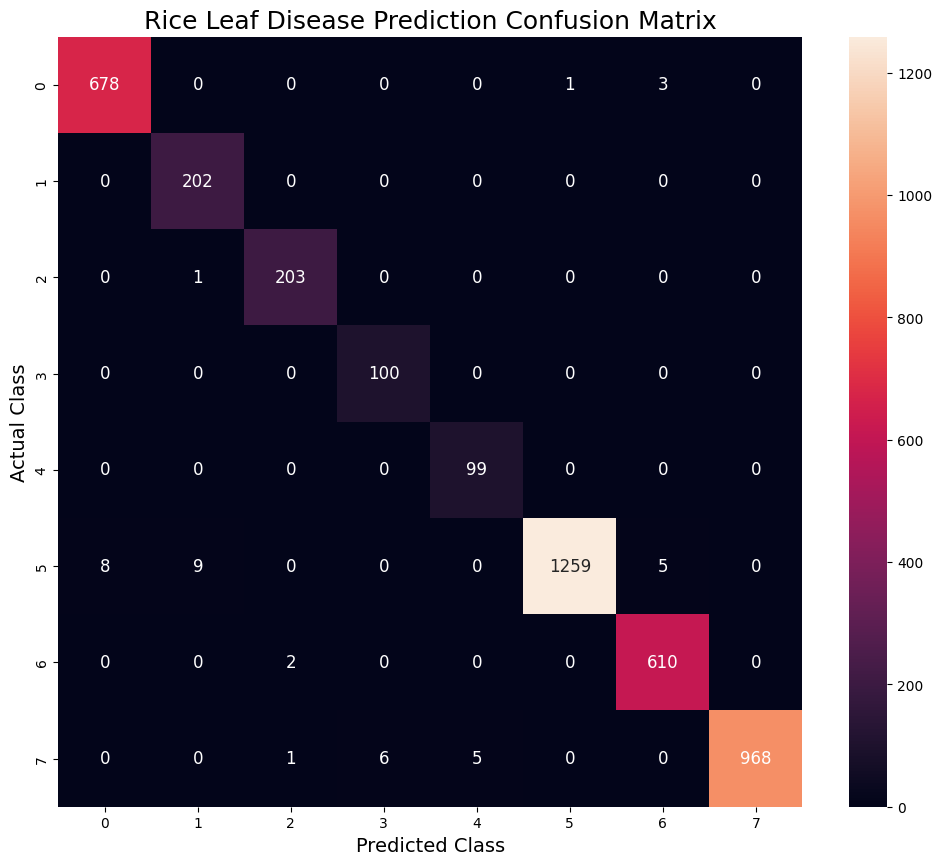

In [41]:
plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    annot_kws={"size": 12}
)
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("Actual Class", fontsize=14)
plt.title("Rice Leaf Disease Prediction Confusion Matrix", fontsize=18)
plt.show()